Saved plot to step1_kraus_decay.png
Max deviation (T1 curve): 1.13e-14
Max deviation (T2 curve): 1.83e-15


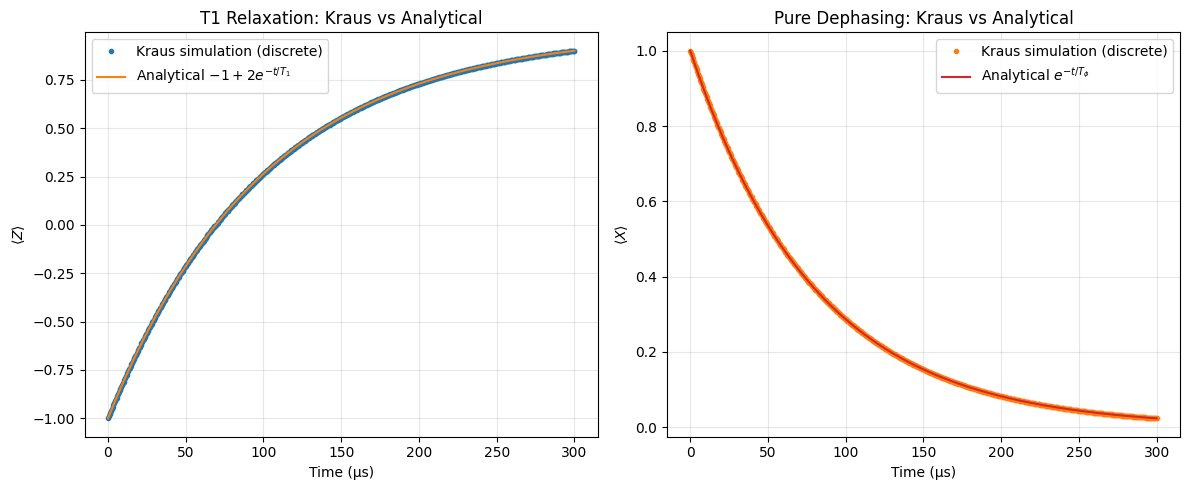

In [12]:


import numpy as np
import matplotlib.pyplot as plt


I2 = np.eye(2, dtype=complex)
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)


def bloch_vector(rho):
    """Extract (rx, ry, rz) from a 2x2 density matrix."""
    rx = np.real(np.trace(rho @ sx))
    ry = np.real(np.trace(rho @ sy))
    rz = np.real(np.trace(rho @ sz))
    return rx, ry, rz


def rho_from_bloch(rx, ry, rz):
    return 0.5 * (I2 + rx * sx + ry * sy + rz * sz)



def amplitude_damping_kraus(gamma):
    """
    Amplitude damping channel (T1 relaxation) for a single small time step.
    gamma = probability of decay (1 -> 0) in this step.
    """
    K0 = np.array([[1, 0], [0, np.sqrt(1 - gamma)]], dtype=complex)
    K1 = np.array([[0, np.sqrt(gamma)], [0, 0]], dtype=complex)
    return [K0, K1]


def phase_damping_kraus(lam):
    """
    Phase damping channel (pure dephasing) for a single small time step.
    lam = probability of a "which-path" scattering event in this step.
    """
    K0 = np.array([[1, 0], [0, np.sqrt(1 - lam)]], dtype=complex)
    K1 = np.array([[0, 0], [0, np.sqrt(lam)]], dtype=complex)
    return [K0, K1]


def apply_channel(rho, kraus_ops):
    return sum(K @ rho @ K.conj().T for K in kraus_ops)



def simulate_t1(T1, dt, n_steps, initial_state="excited"):
    """Simulate energy relaxation |1><1| -> |0><0| via repeated amplitude damping."""
    rho = np.array([[0, 0], [0, 1]], dtype=complex) if initial_state == "excited" \
        else np.array([[1, 0], [0, 0]], dtype=complex)

    gamma = 1 - np.exp(-dt / T1)  # per-step decay probability
    rz_list = [bloch_vector(rho)[2]]

    for _ in range(n_steps):
        rho = apply_channel(rho, amplitude_damping_kraus(gamma))
        rz_list.append(bloch_vector(rho)[2])

    times = np.arange(n_steps + 1) * dt
    return times, np.array(rz_list)


def simulate_t2(Tphi, dt, n_steps):
    """Simulate pure dephasing starting from |+> via repeated phase damping."""
    rho = 0.5 * np.array([[1, 1], [1, 1]], dtype=complex)  # |+><+|

    # Note: the phase-damping Kraus map shrinks off-diagonal coherence by
    # sqrt(1-lam) per step, so to get an overall coherence decay of
    # exp(-t/Tphi) we need sqrt(1-lam) = exp(-dt/Tphi), i.e. lam = 1 - exp(-2*dt/Tphi).
    lam = 1 - np.exp(-2 * dt / Tphi)
    rx_list = [bloch_vector(rho)[0]]

    for _ in range(n_steps):
        rho = apply_channel(rho, phase_damping_kraus(lam))
        rx_list.append(bloch_vector(rho)[0])

    times = np.arange(n_steps + 1) * dt
    return times, np.array(rx_list)



if __name__ == "__main__":
    T1 = 100e-6   # 100 microseconds
    Tphi = 80e-6  # pure dephasing time
    dt = T1 / 200
    n_steps = 600

    t1_times, rz = simulate_t1(T1, dt, n_steps, initial_state="excited")
    t2_times, rx = simulate_t2(Tphi, dt, n_steps)
    rz_analytical = 1 - 2 * np.exp(-t1_times / T1)
    rx_analytical = np.exp(-t2_times / Tphi)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(t1_times * 1e6, rz, 'o', ms=3, label="Kraus simulation (discrete)")
    axes[0].plot(t1_times * 1e6, rz_analytical, '-', label=r"Analytical $-1+2e^{-t/T_1}$")
    axes[0].set_xlabel("Time (µs)")
    axes[0].set_ylabel(r"$\langle Z \rangle$")
    axes[0].set_title("T1 Relaxation: Kraus vs Analytical")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(t2_times * 1e6, rx, 'o', ms=3, color='tab:orange', label="Kraus simulation (discrete)")
    axes[1].plot(t2_times * 1e6, rx_analytical, '-', color='tab:red', label=r"Analytical $e^{-t/T_\phi}$")
    axes[1].set_xlabel("Time (µs)")
    axes[1].set_ylabel(r"$\langle X \rangle$")
    axes[1].set_title("Pure Dephasing: Kraus vs Analytical")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("kraus_decay.png", dpi=150)
    print("Saved plot to step1_kraus_decay.png")

    max_err_t1 = np.max(np.abs(rz - rz_analytical))
    max_err_t2 = np.max(np.abs(rx - rx_analytical))
    print(f"Max deviation (T1 curve): {max_err_t1:.2e}")
    print(f"Max deviation (T2 curve): {max_err_t2:.2e}")


In [4]:
!pip install qiskit_dynamics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.5/180.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 18.9 MB/s eta 0:00:00
